# Funcion de Interpolación baricéntrica

## Aquí definimos nuestra propia función para interpolación baricéntrica

In [24]:
def barycentric_interpolate2(x,f,xi):
    def w(x): #definimos una función para calcular los pesos baricéntricos
        n=x.shape[0]
        w=np.zeros((n))
        for j in range(n):
            w[j]=1
        for j in range(1,n):
            for k in range(0,j):
                w[k]=w[k]*(x[k]-x[j])
                w[j]=w[j]*(x[j]-x[k])
        for j in range(n):
            w[j]=1/w[j]
        return w

    def lagrange(x,w,xi): #xi es un array por si el usuario quiere evaluar varios puntos
        n=x.shape[0]
        m=xi.shape[0]
        L=np.zeros((m,n))
        for k in range(m):
            a=False
            for j in range(n):
                L[k,j]=0
                if xi[k]==x[j]: #Aquí comparamos el valor en donde evaluamos y los x[j] para ver si son iguales 
                    a=True
                    L[k,j]=1
            if a==False:
                s=0
                for j in range(0,n):
                    l=w[j]/(xi[k]-x[j])
                    L[k,j]=l
                    s=s+l
                for j in range(0,n):
                    L[k,j]=L[k,j]/s
        return L
    
    W=w(x)
    L=lagrange(x,W,xi)
    fi=0
    fi=np.dot(L,f) #Aquí armamos el polnomio de la interpolación, ya solo falta multiplicar por los f y sumar todo, por eso hacemos un como producto punto entre los arrays formados con L y con f
    return fi

## Aquí comparamos nuestra interpolación con la de scipy

In [2]:
from numpy.polynomial import chebyshev
coeffs_cheb = [0] * 11 + [1]
T11 = chebyshev.Chebyshev(coeffs_cheb, [-5, 5])
xp_ch = T11.roots()
print(xp_ch)

[-4.94910721e+00 -4.54815998e+00 -3.77874787e+00 -2.70320409e+00
 -1.40866278e+00 -6.03038648e-16  1.40866278e+00  2.70320409e+00
  3.77874787e+00  4.54815998e+00  4.94910721e+00]


In [23]:
def runge(x):
    """Función de Runge"""
    return 1 / (1 + x ** 2)

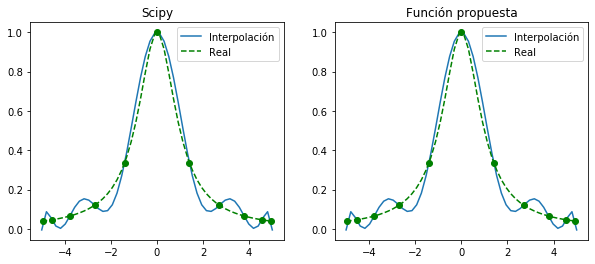

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import barycentric_interpolate
from numpy.polynomial import chebyshev

x = np.linspace(-5, 5)

coeffs_cheb = [0] *11 + [1]
T11 = chebyshev.Chebyshev(coeffs_cheb, [-5, 5])

xp_ch = T11.roots()
fp_ch = runge(xp_ch)

y= barycentric_interpolate(xp_ch, fp_ch, x)

y_ch=barycentric_interpolate2(xp_ch, fp_ch, x)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

l1, = ax1.plot(x, y)
ax1.plot(x, runge(x), '--g')
ax1.plot(xp_ch, fp_ch, 'o', color='green')
ax1.set_title("Scipy")
leg1 = ax1.legend(['Interpolación', 'Real'])


l2, = ax2.plot(x, y_ch)
ax2.plot(x, runge(x), '--g')
ax2.plot(xp_ch, fp_ch, 'og')
ax2.set_ylim(ax1.get_ylim())
ax2.set_title("Función propuesta")
leg2 = ax2.legend(['Interpolación', 'Real'])